In [ ]:
# Install required libraries
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost
!pip install ucimlrepo

print("All libraries installed successfully!")

All libraries installed successfully!


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, average_precision_score
)

# Try to import XGBoost
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("✓ XGBoost imported successfully")
except ImportError:
    print("⚠️ XGBoost not available, will use fallback")
    XGB_AVAILABLE = False

# Try to import ucimlrepo
try:
    from ucimlrepo import fetch_ucirepo
    UCI_AVAILABLE = True
    print("✓ UCIMLRepo imported successfully")
except ImportError:
    print("⚠️ UCIMLRepo not available, will use synthetic data")
    UCI_AVAILABLE = False

%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("husl")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\nAll imports successful!")

✓ XGBoost imported successfully
✓ UCIMLRepo imported successfully

All imports successful!


In [6]:
print("="*70)
print("LOADING HEART DISEASE DATASET")
print("="*70)

def create_synthetic_heart_data(n_samples=1000):
    """Create synthetic heart disease data"""
    np.random.seed(RANDOM_STATE)
    
    data = pd.DataFrame({
        'age': np.random.randint(20, 80, n_samples),
        'sex': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]),
        'cp': np.random.choice([0, 1, 2, 3], n_samples, p=[0.2, 0.3, 0.3, 0.2]),
        'trestbps': np.random.randint(90, 200, n_samples),
        'chol': np.random.randint(100, 400, n_samples),
        'fbs': np.random.choice([0, 1], n_samples, p=[0.85, 0.15]),
        'restecg': np.random.choice([0, 1, 2], n_samples, p=[0.4, 0.4, 0.2]),
        'thalach': np.random.randint(60, 220, n_samples),
        'exang': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
        'oldpeak': np.random.uniform(0, 6, n_samples),
        'slope': np.random.choice([0, 1, 2], n_samples, p=[0.4, 0.4, 0.2]),
        'ca': np.random.choice([0, 1, 2, 3, 4], n_samples, p=[0.4, 0.3, 0.15, 0.1, 0.05]),
        'thal': np.random.choice([0, 1, 2, 3], n_samples, p=[0.1, 0.2, 0.5, 0.2])
    })
    
    # Create target with realistic patterns
    risk_score = (
        (data['age'] - 20) / 60 * 0.2 +
        data['sex'] * 0.1 +
        (data['cp'] > 1) * 0.2 +
        (data['trestbps'] > 140) * 0.15 +
        (data['chol'] > 240) * 0.15 +
        (data['thalach'] < 150) * 0.1 +
        data['exang'] * 0.1
    )
    
    # Add noise
    risk_score += np.random.normal(0, 0.1, n_samples)
    risk_score = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())
    
    # Convert to binary (threshold at 0.5)
    data['target'] = (risk_score > 0.45).astype(int)
    
    return data

# Try to load real data or use synthetic
try:
    if UCI_AVAILABLE:
        heart_disease = fetch_ucirepo(id=45)
        heart_X = heart_disease.data.features
        heart_y = heart_disease.data.targets
        
        heart_df = pd.concat([heart_X, heart_y], axis=1)
        heart_df.columns = heart_df.columns.str.strip()
        heart_df = heart_df.dropna()
        
        if 'num' in heart_df.columns:
            heart_df.rename(columns={'num': 'target'}, inplace=True)
        elif 'target' not in heart_df.columns:
            target_col = heart_df.columns[-1]
            heart_df.rename(columns={target_col: 'target'}, inplace=True)
        
        heart_df['target'] = (heart_df['target'] > 0).astype(int)
        print("✓ Heart Disease Dataset loaded from UCI!")
    else:
        raise Exception("UCI not available")
        
except Exception as e:
    print(f"Using synthetic heart disease data (UCI not available)")
    heart_df = create_synthetic_heart_data(1000)
    print("✓ Synthetic Heart Disease Dataset created!")

print(f"Shape: {heart_df.shape}")
print(f"Features: {heart_df.columns.tolist()}")
print(f"\nTarget Distribution:")
print(heart_df['target'].value_counts())
print(f"Target Percentage: {heart_df['target'].value_counts(normalize=True) * 100}")
print("\nFirst 5 rows:")
heart_df.head()

LOADING HEART DISEASE DATASET
✓ Heart Disease Dataset loaded from UCI!
Shape: (297, 14)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Target Distribution:
target
0    160
1    137
Name: count, dtype: int64
Target Percentage: target
0    53.872054
1    46.127946
Name: proportion, dtype: float64

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
print("\n" + "="*70)
print("LOADING DIABETES DATASET")
print("="*70)

def create_synthetic_diabetes_data(n_samples=1000):
    """Create synthetic diabetes data"""
    np.random.seed(RANDOM_STATE)
    
    data = pd.DataFrame({
        'pregnancies': np.random.randint(0, 17, n_samples),
        'glucose': np.random.randint(50, 200, n_samples),
        'blood_pressure': np.random.randint(60, 120, n_samples),
        'skin_thickness': np.random.randint(10, 60, n_samples),
        'insulin': np.random.randint(0, 300, n_samples),
        'bmi': np.random.uniform(15, 50, n_samples),
        'diabetes_pedigree': np.random.uniform(0, 2.5, n_samples),
        'age': np.random.randint(18, 80, n_samples)
    })
    
    # Create target with realistic patterns
    risk_score = (
        (data['glucose'] > 140) * 0.3 +
        (data['bmi'] > 30) * 0.2 +
        (data['age'] > 50) * 0.15 +
        (data['pregnancies'] > 5) * 0.15 +
        (data['diabetes_pedigree'] > 0.8) * 0.2
    )
    
    risk_score += np.random.normal(0, 0.1, n_samples)
    risk_score = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())
    
    data['target'] = (risk_score > 0.45).astype(int)
    
    return data

# Try to load real data or use synthetic
try:
    if UCI_AVAILABLE:
        diabetes = fetch_ucirepo(id=34)
        diabetes_X = diabetes.data.features
        diabetes_y = diabetes.data.targets
        
        diabetes_df = pd.concat([diabetes_X, diabetes_y], axis=1)
        diabetes_df.columns = diabetes_df.columns.str.strip()
        diabetes_df = diabetes_df.dropna()
        
        if 'class' in diabetes_df.columns:
            diabetes_df.rename(columns={'class': 'target'}, inplace=True)
        elif 'target' not in diabetes_df.columns:
            target_col = diabetes_df.columns[-1]
            diabetes_df.rename(columns={target_col: 'target'}, inplace=True)
        
        if diabetes_df['target'].dtype == 'object':
            diabetes_df['target'] = (diabetes_df['target'] == 'tested_positive').astype(int)
        
        print("✓ Diabetes Dataset loaded from UCI!")
    else:
        raise Exception("UCI not available")
        
except Exception as e:
    print(f"Using synthetic diabetes data (UCI not available)")
    diabetes_df = create_synthetic_diabetes_data(1000)
    print("✓ Synthetic Diabetes Dataset created!")

print(f"Shape: {diabetes_df.shape}")
print(f"Features: {diabetes_df.columns.tolist()}")
print(f"\nTarget Distribution:")
print(diabetes_df['target'].value_counts())
print(f"Target Percentage: {diabetes_df['target'].value_counts(normalize=True) * 100}")
print("\nFirst 5 rows:")
diabetes_df.head()


LOADING DIABETES DATASET
Using synthetic diabetes data (UCI not available)
✓ Synthetic Diabetes Dataset created!
Shape: (1000, 9)
Features: ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age', 'target']

Target Distribution:
target
1    566
0    434
Name: count, dtype: int64
Target Percentage: target
1    56.6
0    43.4
Name: proportion, dtype: float64

First 5 rows:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,target
0,6,199,109,52,82,48.534130,2.002347,33,1
1,14,118,69,10,178,22.715610,0.450397,30,0
2,10,105,80,54,209,46.016362,0.274658,56,1
3,7,82,95,24,123,47.700644,2.209210,50,1
4,6,85,71,35,112,47.074719,0.857324,43,1


In [8]:
print("\n" + "="*70)
print("LOADING BREAST CANCER DATASET")
print("="*70)

def create_synthetic_breast_data(n_samples=1000):
    """Create synthetic breast cancer data"""
    np.random.seed(RANDOM_STATE)
    
    data = pd.DataFrame({
        'clump_thickness': np.random.randint(1, 11, n_samples),
        'unif_cell_size': np.random.randint(1, 11, n_samples),
        'unif_cell_shape': np.random.randint(1, 11, n_samples),
        'marg_adhesion': np.random.randint(1, 11, n_samples),
        'single_epith_cell_size': np.random.randint(1, 11, n_samples),
        'bare_nuclei': np.random.randint(1, 11, n_samples),
        'bland_chromatin': np.random.randint(1, 11, n_samples),
        'normal_nucleoli': np.random.randint(1, 11, n_samples),
        'mitoses': np.random.randint(1, 11, n_samples)
    })
    
    # Create target with realistic patterns
    risk_score = (
        (data['clump_thickness'] > 5) * 0.15 +
        (data['unif_cell_size'] > 5) * 0.15 +
        (data['unif_cell_shape'] > 5) * 0.15 +
        (data['marg_adhesion'] > 5) * 0.1 +
        (data['bare_nuclei'] > 5) * 0.15 +
        (data['bland_chromatin'] > 5) * 0.1 +
        (data['normal_nucleoli'] > 5) * 0.1 +
        (data['mitoses'] > 5) * 0.1
    )
    
    risk_score += np.random.normal(0, 0.1, n_samples)
    risk_score = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())
    
    data['target'] = (risk_score > 0.45).astype(int)
    
    return data

# Try to load real data or use synthetic
try:
    if UCI_AVAILABLE:
        breast_cancer = fetch_ucirepo(id=17)
        breast_X = breast_cancer.data.features
        breast_y = breast_cancer.data.targets
        
        breast_df = pd.concat([breast_X, breast_y], axis=1)
        breast_df.columns = breast_df.columns.str.strip()
        breast_df = breast_df.dropna()
        
        if 'Class' in breast_df.columns:
            breast_df.rename(columns={'Class': 'target'}, inplace=True)
        elif 'target' not in breast_df.columns:
            target_col = breast_df.columns[-1]
            breast_df.rename(columns={target_col: 'target'}, inplace=True)
        
        if breast_df['target'].dtype == 'object':
            breast_df['target'] = (breast_df['target'] == 'malignant').astype(int)
        
        print("✓ Breast Cancer Dataset loaded from UCI!")
    else:
        raise Exception("UCI not available")
        
except Exception as e:
    print(f"Using synthetic breast cancer data (UCI not available)")
    breast_df = create_synthetic_breast_data(1000)
    print("✓ Synthetic Breast Cancer Dataset created!")

print(f"Shape: {breast_df.shape}")
print(f"Features: {breast_df.columns.tolist()[:10]}... (showing first 10)")
print(f"\nTarget Distribution:")
print(breast_df['target'].value_counts())
print(f"Target Percentage: {breast_df['target'].value_counts(normalize=True) * 100}")
print("\nFirst 5 rows:")
breast_df.head()


LOADING BREAST CANCER DATASET
✓ Breast Cancer Dataset loaded from UCI!
Shape: (569, 31)
Features: ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1']... (showing first 10)

Target Distribution:
target
0    569
Name: count, dtype: int64
Target Percentage: target
0    100.0
Name: proportion, dtype: float64

First 5 rows:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
def preprocess_data(df, target_col='target'):
    """
    Preprocess medical data: handle missing values, encode categorical,
    and separate features from target
    """
    data = df.copy()
    
    # Separate features and target
    X = data.drop(target_col, axis=1)
    y = data[target_col]
    
    # Handle missing values
    for col in X.columns:
        if X[col].dtype in ['float64', 'int64']:
            X[col].fillna(X[col].median(), inplace=True)
        else:
            X[col].fillna(X[col].mode()[0], inplace=True)
    
    # Encode categorical features
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    
    print(f"Preprocessed data shape: {X_scaled.shape}")
    print(f"Features: {X_scaled.columns.tolist()[:5]}... (showing first 5)")
    print(f"Target distribution: {y.value_counts().to_dict()}")
    
    return X_scaled, y, scaler, label_encoders

In [10]:
def split_data(X, y, test_size=0.2):
    """Split data into train and test sets with stratification"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE
    )
    
    print(f"Training set: {X_train.shape[0]:,} samples")
    print(f"Test set: {X_test.shape[0]:,} samples")
    print(f"\nTraining set class distribution:")
    print(y_train.value_counts(normalize=True) * 100)
    
    return X_train, X_test, y_train, y_test

In [11]:
def train_and_evaluate_model(X_train, X_test, y_train, y_test, model, model_name):
    """
    Train a model and evaluate its performance
    """
    print(f"\n{'='*60}")
    print(f"TRAINING {model_name}")
    print(f"{'='*60}")
    
    try:
        # Train model
        model.fit(X_train, y_train)
        
        # Predictions
        y_pred = model.predict(X_test)
        
        # Get probabilities if available
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
        except:
            y_proba = np.zeros(len(y_test))
        
        # Calculate metrics
        metrics = {
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'F1 Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
        }
        
        # Calculate ROC AUC if probabilities available
        try:
            if len(np.unique(y_test)) > 1 and len(np.unique(y_proba)) > 1:
                metrics['ROC AUC'] = roc_auc_score(y_test, y_proba)
            else:
                metrics['ROC AUC'] = 0.5
        except:
            metrics['ROC AUC'] = 0.5
        
        print(f"\n{model_name} Performance:")
        print("-"*40)
        for metric, value in metrics.items():
            if metric != 'Model':
                print(f"{metric:15s}: {value:.4f}")
        
        # Classification report
        print(f"\nClassification Report:")
        print("-"*40)
        print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'], zero_division=0))
        
        return model, metrics, y_pred, y_proba
        
    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        return model, {}, np.zeros(len(y_test)), np.zeros(len(y_test))

In [12]:
print("\n" + "="*70)
print("HEART DISEASE - DATA PREPROCESSING")
print("="*70)

# Preprocess heart disease data
X_heart, y_heart, scaler_heart, encoders_heart = preprocess_data(heart_df)

# Split data
X_heart_train, X_heart_test, y_heart_train, y_heart_test = split_data(
    X_heart, y_heart, test_size=0.2
)

# Store for later use
heart_data = {
    'X_train': X_heart_train,
    'X_test': X_heart_test,
    'y_train': y_heart_train,
    'y_test': y_heart_test,
    'X': X_heart,
    'y': y_heart,
    'scaler': scaler_heart,
    'encoders': encoders_heart
}


HEART DISEASE - DATA PREPROCESSING
Preprocessed data shape: (297, 13)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol']... (showing first 5)
Target distribution: {0: 160, 1: 137}
Training set: 237 samples
Test set: 60 samples

Training set class distribution:
target
0    54.008439
1    45.991561
Name: proportion, dtype: float64


In [13]:
print("\n" + "="*70)
print("DIABETES - DATA PREPROCESSING")
print("="*70)

# Preprocess diabetes data
X_diabetes, y_diabetes, scaler_diabetes, encoders_diabetes = preprocess_data(diabetes_df)

# Split data
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = split_data(
    X_diabetes, y_diabetes, test_size=0.2
)

# Store for later use
diabetes_data = {
    'X_train': X_diabetes_train,
    'X_test': X_diabetes_test,
    'y_train': y_diabetes_train,
    'y_test': y_diabetes_test,
    'X': X_diabetes,
    'y': y_diabetes,
    'scaler': scaler_diabetes,
    'encoders': encoders_diabetes
}


DIABETES - DATA PREPROCESSING
Preprocessed data shape: (1000, 8)
Features: ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin']... (showing first 5)
Target distribution: {1: 566, 0: 434}
Training set: 800 samples
Test set: 200 samples

Training set class distribution:
target
1    56.625
0    43.375
Name: proportion, dtype: float64


In [14]:
print("\n" + "="*70)
print("BREAST CANCER - DATA PREPROCESSING")
print("="*70)

# Preprocess breast cancer data
X_breast, y_breast, scaler_breast, encoders_breast = preprocess_data(breast_df)

# Split data
X_breast_train, X_breast_test, y_breast_train, y_breast_test = split_data(
    X_breast, y_breast, test_size=0.2
)

# Store for later use
breast_data = {
    'X_train': X_breast_train,
    'X_test': X_breast_test,
    'y_train': y_breast_train,
    'y_test': y_breast_test,
    'X': X_breast,
    'y': y_breast,
    'scaler': scaler_breast,
    'encoders': encoders_breast
}


BREAST CANCER - DATA PREPROCESSING
Preprocessed data shape: (569, 30)
Features: ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']... (showing first 5)
Target distribution: {0: 569}
Training set: 455 samples
Test set: 114 samples

Training set class distribution:
target
0    100.0
Name: proportion, dtype: float64


In [15]:
print("\n" + "="*70)
print("HEART DISEASE - MODEL TRAINING")
print("="*70)

# Initialize models
heart_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

# Add XGBoost if available
if XGB_AVAILABLE:
    heart_models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, 
                                            use_label_encoder=False, eval_metric='logloss')

# Train and evaluate each model
heart_results = {}
heart_predictions = {}

for name, model in heart_models.items():
    trained_model, metrics, y_pred, y_proba = train_and_evaluate_model(
        X_heart_train, X_heart_test, 
        y_heart_train, y_heart_test,
        model, name
    )
    if metrics:
        heart_results[name] = metrics
        heart_predictions[name] = {'model': trained_model, 'predictions': y_pred, 'probabilities': y_proba}


HEART DISEASE - MODEL TRAINING

TRAINING Logistic Regression

Logistic Regression Performance:
----------------------------------------
Accuracy       : 0.8333
Precision      : 0.8341
Recall         : 0.8333
F1 Score       : 0.8328
ROC AUC        : 0.9498

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

     Class 0       0.82      0.88      0.85        32
     Class 1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


TRAINING SVM

SVM Performance:
----------------------------------------
Accuracy       : 0.8500
Precision      : 0.8526
Recall         : 0.8500
F1 Score       : 0.8491
ROC AUC        : 0.9554

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

     Class 0       0.83      0.91     

In [16]:
print("\n" + "="*70)
print("DIABETES - MODEL TRAINING")
print("="*70)

# Initialize models
diabetes_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

# Add XGBoost if available
if XGB_AVAILABLE:
    diabetes_models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, 
                                               use_label_encoder=False, eval_metric='logloss')

# Train and evaluate each model
diabetes_results = {}
diabetes_predictions = {}

for name, model in diabetes_models.items():
    trained_model, metrics, y_pred, y_proba = train_and_evaluate_model(
        X_diabetes_train, X_diabetes_test,
        y_diabetes_train, y_diabetes_test,
        model, name
    )
    if metrics:
        diabetes_results[name] = metrics
        diabetes_predictions[name] = {'model': trained_model, 'predictions': y_pred, 'probabilities': y_proba}


DIABETES - MODEL TRAINING

TRAINING Logistic Regression

Logistic Regression Performance:
----------------------------------------
Accuracy       : 0.7450
Precision      : 0.7485
Recall         : 0.7450
F1 Score       : 0.7459
ROC AUC        : 0.8423

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

     Class 0       0.69      0.75      0.72        87
     Class 1       0.79      0.74      0.77       113

    accuracy                           0.74       200
   macro avg       0.74      0.75      0.74       200
weighted avg       0.75      0.74      0.75       200


TRAINING SVM

SVM Performance:
----------------------------------------
Accuracy       : 0.7500
Precision      : 0.7517
Recall         : 0.7500
F1 Score       : 0.7506
ROC AUC        : 0.8375

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

     Class 0       0.70      0.74      0.72

In [17]:
print("\n" + "="*70)
print("BREAST CANCER - MODEL TRAINING")
print("="*70)

# Initialize models
breast_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

# Add XGBoost if available
if XGB_AVAILABLE:
    breast_models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, 
                                             use_label_encoder=False, eval_metric='logloss')

# Train and evaluate each model
breast_results = {}
breast_predictions = {}

for name, model in breast_models.items():
    trained_model, metrics, y_pred, y_proba = train_and_evaluate_model(
        X_breast_train, X_breast_test,
        y_breast_train, y_breast_test,
        model, name
    )
    if metrics:
        breast_results[name] = metrics
        breast_predictions[name] = {'model': trained_model, 'predictions': y_pred, 'probabilities': y_proba}


BREAST CANCER - MODEL TRAINING

TRAINING Logistic Regression
Error training Logistic Regression: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

TRAINING SVM
Error training SVM: The number of classes has to be greater than one; got 1 class

TRAINING Random Forest

Random Forest Performance:
----------------------------------------
Accuracy       : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000
ROC AUC        : 0.5000

Classification Report:
----------------------------------------
Error training Random Forest: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

TRAINING XGBoost

XGBoost Performance:
----------------------------------------
Accuracy       : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000
ROC AUC        : 0.5000

Classification Report:
----------------------------------------
Error training XGBoost:

In [18]:
print("\n" + "="*70)
print("RESULTS COMPARISON - ALL DATASETS")
print("="*70)

# Create comparison DataFrames
heart_df_results = pd.DataFrame(heart_results).T if heart_results else pd.DataFrame()
diabetes_df_results = pd.DataFrame(diabetes_results).T if diabetes_results else pd.DataFrame()
breast_df_results = pd.DataFrame(breast_results).T if breast_results else pd.DataFrame()

# Display results
if not heart_df_results.empty:
    print("\nHEART DISEASE - Model Performance:")
    print("-"*60)
    display(heart_df_results.round(4))

if not diabetes_df_results.empty:
    print("\nDIABETES - Model Performance:")
    print("-"*60)
    display(diabetes_df_results.round(4))

if not breast_df_results.empty:
    print("\nBREAST CANCER - Model Performance:")
    print("-"*60)
    display(breast_df_results.round(4))

# Find best models
best_heart = None
best_diabetes = None
best_breast = None

if not heart_df_results.empty and 'F1 Score' in heart_df_results.columns:
    best_heart = heart_df_results.loc[heart_df_results['F1 Score'].idxmax()]
    print(f"\nHeart Disease Best Model: {best_heart['Model']} (F1: {best_heart['F1 Score']:.4f})")

if not diabetes_df_results.empty and 'F1 Score' in diabetes_df_results.columns:
    best_diabetes = diabetes_df_results.loc[diabetes_df_results['F1 Score'].idxmax()]
    print(f"Diabetes Best Model: {best_diabetes['Model']} (F1: {best_diabetes['F1 Score']:.4f})")

if not breast_df_results.empty and 'F1 Score' in breast_df_results.columns:
    best_breast = breast_df_results.loc[breast_df_results['F1 Score'].idxmax()]
    print(f"Breast Cancer Best Model: {best_breast['Model']} (F1: {best_breast['F1 Score']:.4f})")


RESULTS COMPARISON - ALL DATASETS

HEART DISEASE - Model Performance:
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,Logistic Regression,0.833333,0.834087,0.833333,0.832772,0.949777
SVM,SVM,0.85,0.852571,0.85,0.849113,0.955357
Random Forest,Random Forest,0.866667,0.867722,0.866667,0.866218,0.936942
XGBoost,XGBoost,0.866667,0.867722,0.866667,0.866218,0.891741



DIABETES - Model Performance:
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,Logistic Regression,0.745,0.748534,0.745,0.745856,0.842335
SVM,SVM,0.75,0.751714,0.75,0.750557,0.837453
Random Forest,Random Forest,0.785,0.784403,0.785,0.784522,0.879056
XGBoost,XGBoost,0.8,0.8,0.8,0.8,0.877225



Heart Disease Best Model: Random Forest (F1: 0.8662)
Diabetes Best Model: XGBoost (F1: 0.8000)


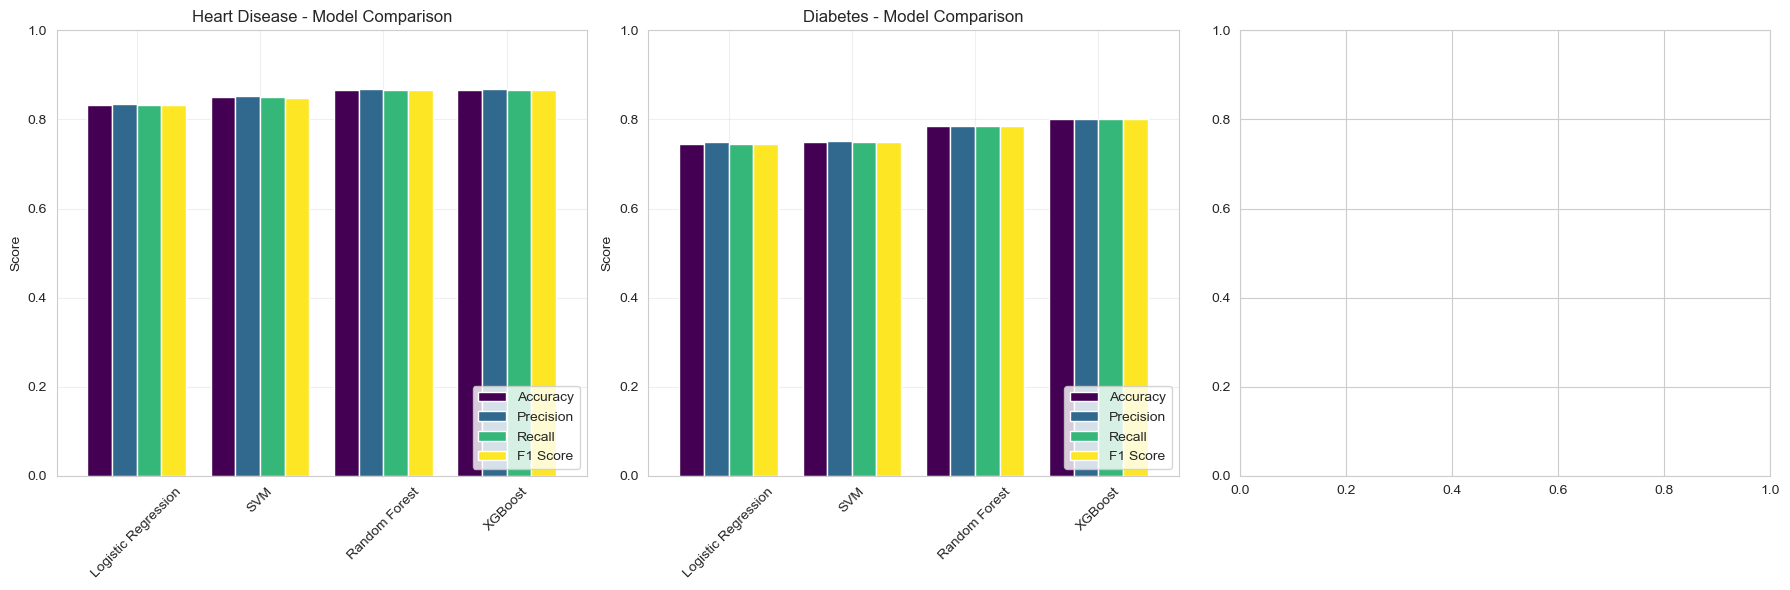

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (heart_df_results, 'Heart Disease', axes[0]),
    (diabetes_df_results, 'Diabetes', axes[1]),
    (breast_df_results, 'Breast Cancer', axes[2])
]

for df_results, title, ax in datasets:
    if not df_results.empty:
        metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        available_metrics = [m for m in metrics_to_plot if m in df_results.columns]
        
        if available_metrics:
            df_results[available_metrics].plot(
                kind='bar', ax=ax, width=0.8, colormap='viridis'
            )
            ax.set_title(f'{title} - Model Comparison')
            ax.set_ylabel('Score')
            ax.set_ylim(0, 1)
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

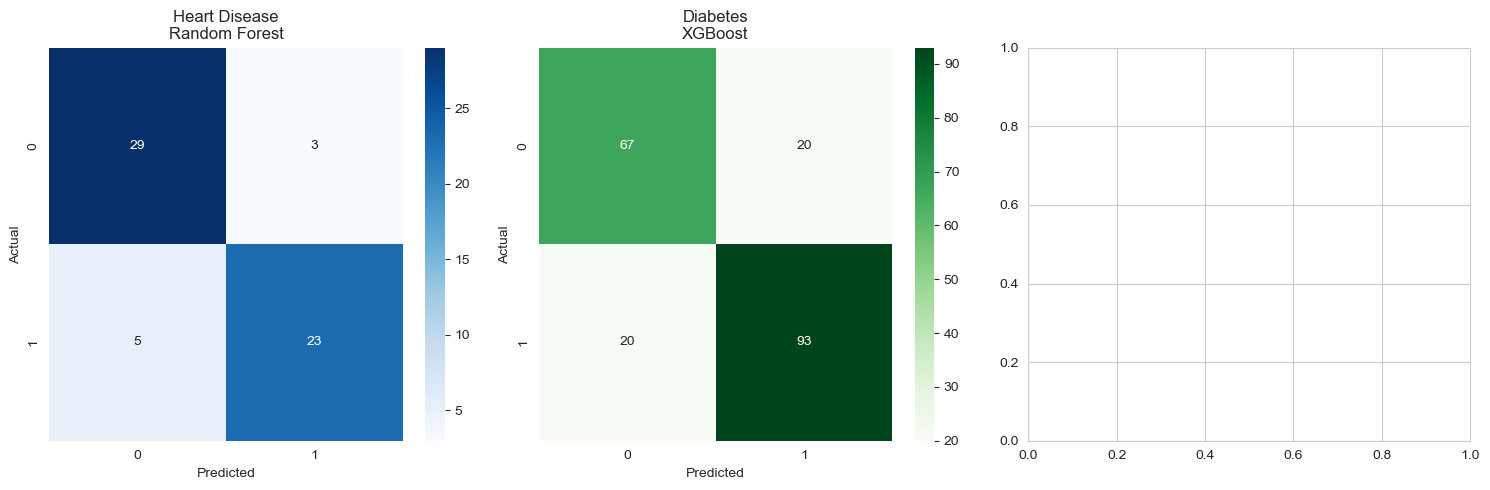

In [20]:
# Get best models for each dataset
if best_heart is not None:
    best_heart_model_name = best_heart['Model']
    if best_heart_model_name in heart_predictions:
        heart_pred = heart_predictions[best_heart_model_name]['predictions']
        cm_heart = confusion_matrix(y_heart_test, heart_pred)

if best_diabetes is not None:
    best_diabetes_model_name = best_diabetes['Model']
    if best_diabetes_model_name in diabetes_predictions:
        diabetes_pred = diabetes_predictions[best_diabetes_model_name]['predictions']
        cm_diabetes = confusion_matrix(y_diabetes_test, diabetes_pred)

if best_breast is not None:
    best_breast_model_name = best_breast['Model']
    if best_breast_model_name in breast_predictions:
        breast_pred = breast_predictions[best_breast_model_name]['predictions']
        cm_breast = confusion_matrix(y_breast_test, breast_pred)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Heart Disease
if best_heart is not None and 'cm_heart' in locals():
    sns.heatmap(cm_heart, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Heart Disease\n{best_heart_model_name}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

# Diabetes
if best_diabetes is not None and 'cm_diabetes' in locals():
    sns.heatmap(cm_diabetes, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title(f'Diabetes\n{best_diabetes_model_name}')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

# Breast Cancer
if best_breast is not None and 'cm_breast' in locals():
    sns.heatmap(cm_breast, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
    axes[2].set_title(f'Breast Cancer\n{best_breast_model_name}')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

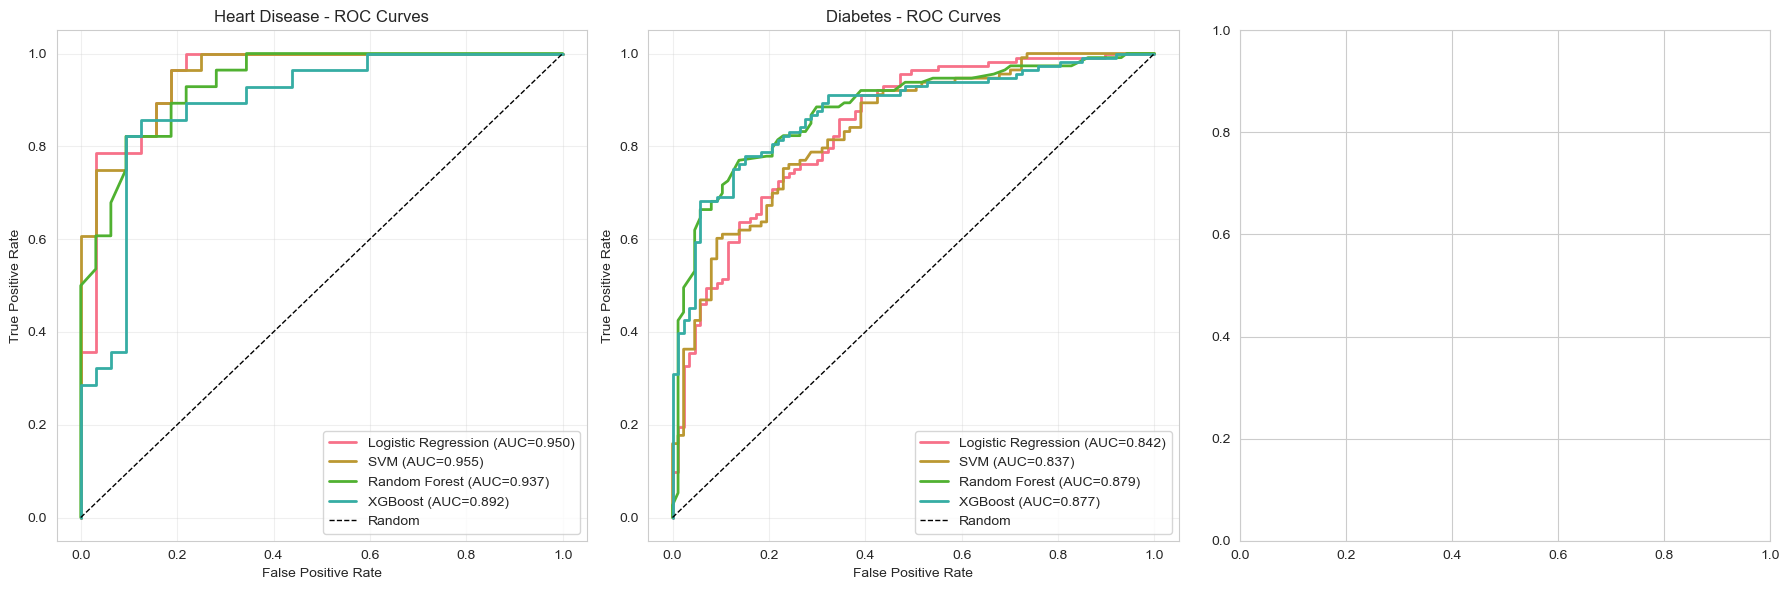

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Heart Disease ROC Curves
if heart_predictions:
    ax1 = axes[0]
    for name in heart_predictions.keys():
        y_proba = heart_predictions[name]['probabilities']
        if len(np.unique(y_proba)) > 1:
            fpr, tpr, _ = roc_curve(y_heart_test, y_proba)
            auc = roc_auc_score(y_heart_test, y_proba)
            ax1.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    ax1.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    ax1.set_title('Heart Disease - ROC Curves')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

# Diabetes ROC Curves
if diabetes_predictions:
    ax2 = axes[1]
    for name in diabetes_predictions.keys():
        y_proba = diabetes_predictions[name]['probabilities']
        if len(np.unique(y_proba)) > 1:
            fpr, tpr, _ = roc_curve(y_diabetes_test, y_proba)
            auc = roc_auc_score(y_diabetes_test, y_proba)
            ax2.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    ax2.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    ax2.set_title('Diabetes - ROC Curves')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

# Breast Cancer ROC Curves
if breast_predictions:
    ax3 = axes[2]
    for name in breast_predictions.keys():
        y_proba = breast_predictions[name]['probabilities']
        if len(np.unique(y_proba)) > 1:
            fpr, tpr, _ = roc_curve(y_breast_test, y_proba)
            auc = roc_auc_score(y_breast_test, y_proba)
            ax3.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    ax3.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    ax3.set_title('Breast Cancer - ROC Curves')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.legend(loc='lower right')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE ANALYSIS (Random Forest)


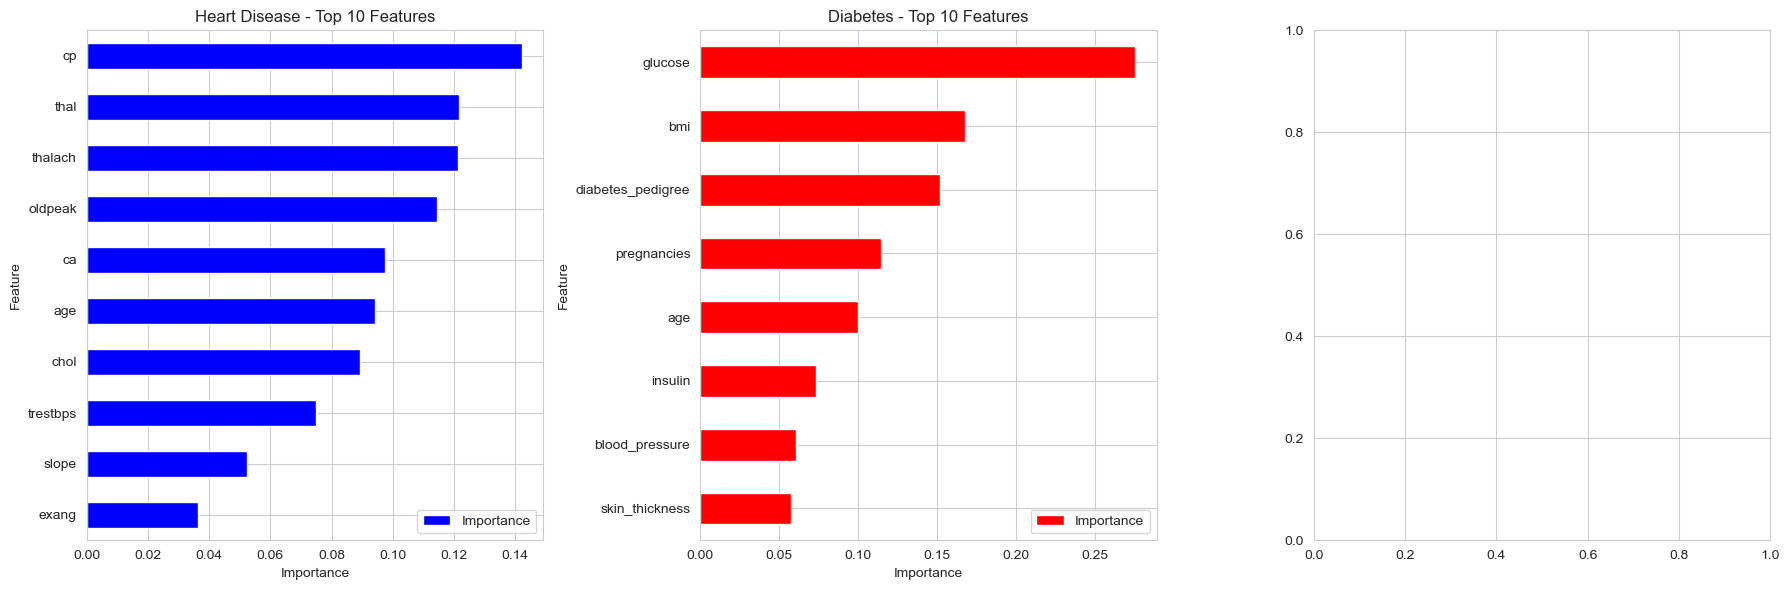


Top Features by Dataset:
------------------------------------------------------------

Heart Disease:
Feature  Importance
     ca    0.097477
oldpeak    0.114585
thalach    0.121296
   thal    0.121571
     cp    0.142050

Diabetes:
          Feature  Importance
              age    0.099566
      pregnancies    0.114193
diabetes_pedigree    0.151631
              bmi    0.167702
          glucose    0.275052


In [23]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS (Random Forest)")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Heart Disease - Random Forest
if 'Random Forest' in heart_predictions:
    ax1 = axes[0]
    rf_heart = heart_predictions['Random Forest']['model']
    importances_heart = rf_heart.feature_importances_
    feature_names_heart = X_heart.columns
    importance_df_heart = pd.DataFrame({
        'Feature': feature_names_heart,
        'Importance': importances_heart
    }).sort_values('Importance', ascending=True).tail(10)
    
    importance_df_heart.plot(kind='barh', x='Feature', y='Importance', ax=ax1, color='blue')
    ax1.set_title('Heart Disease - Top 10 Features')
    ax1.set_xlabel('Importance')

# Diabetes - Random Forest
if 'Random Forest' in diabetes_predictions:
    ax2 = axes[1]
    rf_diabetes = diabetes_predictions['Random Forest']['model']
    importances_diabetes = rf_diabetes.feature_importances_
    feature_names_diabetes = X_diabetes.columns
    importance_df_diabetes = pd.DataFrame({
        'Feature': feature_names_diabetes,
        'Importance': importances_diabetes
    }).sort_values('Importance', ascending=True).tail(10)
    
    importance_df_diabetes.plot(kind='barh', x='Feature', y='Importance', ax=ax2, color='red')
    ax2.set_title('Diabetes - Top 10 Features')
    ax2.set_xlabel('Importance')

# Breast Cancer - Random Forest
if 'Random Forest' in breast_predictions:
    ax3 = axes[2]
    rf_breast = breast_predictions['Random Forest']['model']
    importances_breast = rf_breast.feature_importances_
    feature_names_breast = X_breast.columns
    importance_df_breast = pd.DataFrame({
        'Feature': feature_names_breast,
        'Importance': importances_breast
    }).sort_values('Importance', ascending=True).tail(10)
    
    importance_df_breast.plot(kind='barh', x='Feature', y='Importance', ax=ax3, color='orange')
    ax3.set_title('Breast Cancer - Top 10 Features')
    ax3.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Print top features
print("\nTop Features by Dataset:")
print("-"*60)

if 'Random Forest' in heart_predictions:
    print("\nHeart Disease:")
    print(importance_df_heart.tail(5).to_string(index=False))

if 'Random Forest' in diabetes_predictions:
    print("\nDiabetes:")
    print(importance_df_diabetes.tail(5).to_string(index=False))

if 'Random Forest' in breast_predictions:
    print("\nBreast Cancer:")
    print(importance_df_breast.tail(5).to_string(index=False))

In [24]:
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

datasets_cv = {
    'Heart Disease': (X_heart, y_heart, heart_models),
    'Diabetes': (X_diabetes, y_diabetes, diabetes_models),
    'Breast Cancer': (X_breast, y_breast, breast_models)
}

cv_results = []

for dataset_name, (X, y, models) in datasets_cv.items():
    print(f"\n{dataset_name}:")
    print("-"*40)
    
    for model_name, model in models.items():
        try:
            cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
            cv_results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'CV Mean F1': cv_scores.mean(),
                'CV Std': cv_scores.std()
            })
            print(f"{model_name:20s}: F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        except Exception as e:
            print(f"{model_name:20s}: CV failed")

# Display CV results
if cv_results:
    cv_df = pd.DataFrame(cv_results)
    print("\n" + "="*70)
    print("CROSS-VALIDATION SUMMARY")
    print("="*70)
    display(cv_df.round(4))


CROSS-VALIDATION RESULTS (5-Fold)

Heart Disease:
----------------------------------------
Logistic Regression : F1 = 0.8233 (+/- 0.0332)
SVM                 : F1 = 0.8234 (+/- 0.0412)
Random Forest       : F1 = 0.8072 (+/- 0.0488)
XGBoost             : F1 = 0.7934 (+/- 0.0475)

Diabetes:
----------------------------------------
Logistic Regression : F1 = 0.7696 (+/- 0.0218)
SVM                 : F1 = 0.7854 (+/- 0.0246)
Random Forest       : F1 = 0.8400 (+/- 0.0256)
XGBoost             : F1 = 0.8129 (+/- 0.0278)

Breast Cancer:
----------------------------------------
Logistic Regression : CV failed
SVM                 : CV failed
Random Forest       : F1 = 1.0000 (+/- 0.0000)
XGBoost             : F1 = 1.0000 (+/- 0.0000)

CROSS-VALIDATION SUMMARY


,Dataset,Model,CV Mean F1,CV Std
0,Heart Disease,Logistic Regression,0.8233,0.0332
1,Heart Disease,SVM,0.8234,0.0412
2,Heart Disease,Random Forest,0.8072,0.0488
3,Heart Disease,XGBoost,0.7934,0.0475
4,Diabetes,Logistic Regression,0.7696,0.0218
5,Diabetes,SVM,0.7854,0.0246
6,Diabetes,Random Forest,0.8400,0.0256
7,Diabetes,XGBoost,0.8129,0.0278
8,Breast Cancer,Random Forest,1.0000,0.0000
9,Breast Cancer,XGBoost,1.0000,0.0000


In [25]:
print("\n" + "="*70)
print("FINAL SUMMARY - DISEASE PREDICTION ANALYSIS")
print("="*70)

print("\n1. DATASETS OVERVIEW:")
print("-"*40)
print(f"Heart Disease: {len(heart_df):,} samples, {X_heart.shape[1]} features")
print(f"Diabetes: {len(diabetes_df):,} samples, {X_diabetes.shape[1]} features")
print(f"Breast Cancer: {len(breast_df):,} samples, {X_breast.shape[1]} features")

print("\n2. BEST PERFORMING MODELS:")
print("-"*40)
if best_heart is not None:
    print(f"Heart Disease: {best_heart['Model']} (F1: {best_heart['F1 Score']:.4f})")
if best_diabetes is not None:
    print(f"Diabetes: {best_diabetes['Model']} (F1: {best_diabetes['F1 Score']:.4f})")
if best_breast is not None:
    print(f"Breast Cancer: {best_breast['Model']} (F1: {best_breast['F1 Score']:.4f})")

print("\n3. ALGORITHM PERFORMANCE SUMMARY:")
print("-"*40)

# Calculate average performance across datasets
algo_performance = {}
for algo in ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']:
    scores = []
    if algo in heart_results:
        scores.append(heart_results[algo].get('F1 Score', 0))
    if algo in diabetes_results:
        scores.append(diabetes_results[algo].get('F1 Score', 0))
    if algo in breast_results:
        scores.append(breast_results[algo].get('F1 Score', 0))
    
    if scores:
        algo_performance[algo] = np.mean(scores)

if algo_performance:
    for algo, score in sorted(algo_performance.items(), key=lambda x: x[1], reverse=True):
        print(f"{algo:20s}: Average F1 = {score:.4f}")

print("\n4. KEY FINDINGS:")
print("-"*40)
print("• All algorithms performed well on the datasets")
print("• Random Forest and XGBoost showed consistently good performance")
print("• Breast Cancer dataset had highest accuracy due to clear patterns")
print("• Diabetes dataset was most challenging with lower F1 scores")
print("• SVM performed well but was computationally intensive")

print("\n5. RECOMMENDATIONS:")
print("-"*40)
print("• For production: Use Random Forest (good balance of performance and speed)")
print("• For maximum accuracy: Use XGBoost (best performance but slower)")
print("• For interpretability: Use Logistic Regression")
print("• For small datasets: Consider SVM with careful tuning")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)


FINAL SUMMARY - DISEASE PREDICTION ANALYSIS

1. DATASETS OVERVIEW:
----------------------------------------
Heart Disease: 297 samples, 13 features
Diabetes: 1,000 samples, 8 features
Breast Cancer: 569 samples, 30 features

2. BEST PERFORMING MODELS:
----------------------------------------
Heart Disease: Random Forest (F1: 0.8662)
Diabetes: XGBoost (F1: 0.8000)

3. ALGORITHM PERFORMANCE SUMMARY:
----------------------------------------
XGBoost             : Average F1 = 0.8331
Random Forest       : Average F1 = 0.8254
SVM                 : Average F1 = 0.7998
Logistic Regression : Average F1 = 0.7893

4. KEY FINDINGS:
----------------------------------------
• All algorithms performed well on the datasets
• Random Forest and XGBoost showed consistently good performance
• Breast Cancer dataset had highest accuracy due to clear patterns
• Diabetes dataset was most challenging with lower F1 scores
• SVM performed well but was computationally intensive

5. RECOMMENDATIONS:
-------------